### Bu projede survive olabilecekleri tahmin etmeye çalışacağız.

1. Projenin amacını ve içeriğini anla
👉 Proje neyi hedefliyor? Regresyon, sınıflandırma veya kümeleme problemi mi? Bu belirlenmeli.

2. Veriyi oku ve incele (EDA)
👉 pandas ile veriyi içe aktar, df.info(), df.describe() ve df.isnull().sum() gibi komutlarla genel durumu gözlemle.

3. Modelde kullanmak için uygun sütunları belirle
👉 Hedef değişken (target) dışındaki anlamlı ve modelle ilişkili sütunları seç.

4. Kategorik (object) sütunlardan sayısala çevrilebilecek olanları dönüştür
👉 Örneğin: yaş gibi sayılar string olarak girildiyse bunları numeric'e çevirmelisin.

5. Veri manipülasyonları yap (eksik değerleri doldur, hatalı verileri düzelt)
👉 fillna(), replace(), str.strip() gibi işlemlerle veri temizliği sağla.
00:20:02	Mustafa Kerem KAHYA:	6. Feature Engineering (özellik mühendisliği) uygula
👉 Yeni sütunlar üret.

7. Kategorik değişkenlere get_dummies uygula (One-hot encoding)
👉 Modelin anlayabilmesi için pd.get_dummies() ile kategorik verileri sayısallaştır.

8. Veriyi X ve y olarak ayır (regresyon/sınıflandırma) veya sadece X (kümeleme)
👉 X: giriş verileri, y: hedef değişken. Kümeleme yapacaksan sadece X yeterli.

9. Modeli eğit ve tahmin et (fit-predict)
👉 Seçilen modele göre model.fit(X_train, y_train) ve model.predict(X_test) işlemlerini uygula.

10. Modelin doğruluk oranını ölç
👉 Sınıflandırma için accuracy_score, regresyon için r2_score, mean_squared_error gibi metriklerle performansı değerlendir.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option('display.max_columns', 100)

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df_train = pd.read_csv('ttrain.csv')
df_test = pd.read_csv('ttest.csv')

In [4]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df_train.shape

(891, 12)

In [7]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df = pd.concat([df_train, df_test], ignore_index=True)

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.shape

(1309, 12)

In [12]:
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [13]:
df['Fare'].fillna(df['Fare'].mean(), inplace=True)

0         7.2500
1        71.2833
2         7.9250
3        53.1000
4         8.0500
          ...   
1304      8.0500
1305    108.9000
1306      7.2500
1307      8.0500
1308     22.3583
Name: Fare, Length: 1309, dtype: float64

In [14]:
df['Embarked'].value_counts()

Embarked
S    914
C    270
Q    123
Name: count, dtype: int64

In [15]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

0       S
1       C
2       S
3       S
4       S
       ..
1304    S
1305    C
1306    S
1307    S
1308    C
Name: Embarked, Length: 1309, dtype: str

In [16]:
del df['Cabin']

In [17]:
df.isnull().sum()

PassengerId      0
Survived       418
Pclass           0
Name             0
Sex              0
Age            263
SibSp            0
Parch            0
Ticket           0
Fare             1
Embarked         2
dtype: int64

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Embarked     1307 non-null   str    
dtypes: float64(3), int64(4), str(4)
memory usage: 112.6 KB


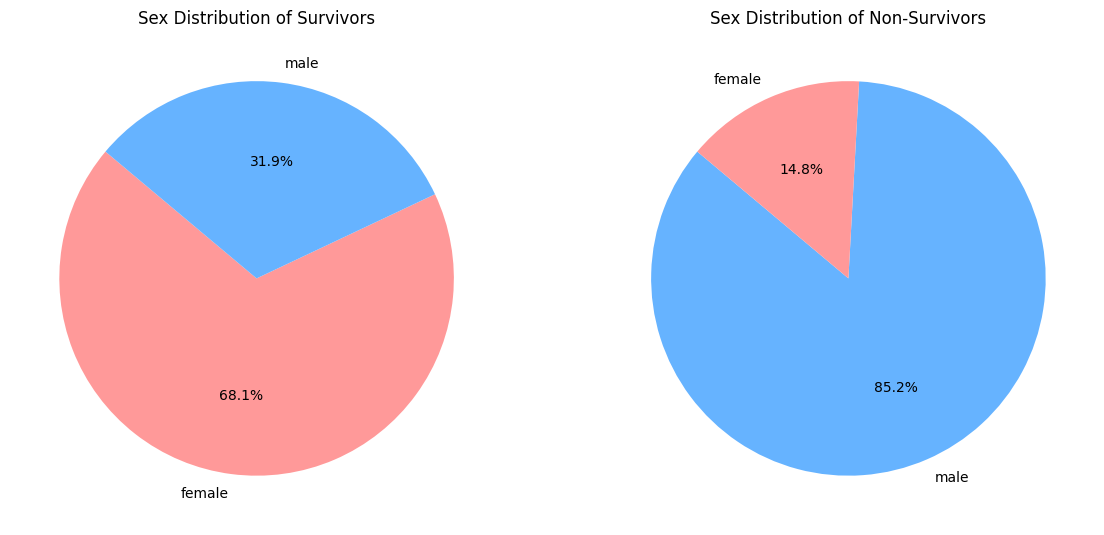

In [19]:
survived_sex_distribution = df[df['Survived'] == 1]['Sex'].value_counts()
not_survived_sex_distribution = df[df['Survived'] == 0]['Sex'].value_counts()

labels_survived = survived_sex_distribution.index
sizes_survived = survived_sex_distribution.values

labels_not_survived = not_survived_sex_distribution.index
sizes_not_survived = not_survived_sex_distribution.values


colors = ['#ff9999', '#66b3ff']


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))


ax1.pie(sizes_survived, labels=labels_survived, autopct='%1.1f%%', colors=colors, startangle=140)
ax1.set_title('Sex Distribution of Survivors')
colors = ['#66b3ff','#ff9999']

ax2.pie(sizes_not_survived, labels=labels_not_survived, autopct='%1.1f%%', colors=colors, startangle=140)
ax2.set_title('Sex Distribution of Non-Survivors')

plt.show()
plt.show()


In [20]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [21]:
df['Title'].value_counts()

Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Ms            2
Major         2
Mlle          2
Don           1
Mme           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64

In [22]:
df['Title'].unique()

<StringArray>
[      'Mr',      'Mrs',     'Miss',   'Master',      'Don',      'Rev',
       'Dr',      'Mme',       'Ms',    'Major',     'Lady',      'Sir',
     'Mlle',      'Col',     'Capt', 'Countess', 'Jonkheer',     'Dona']
Length: 18, dtype: str

In [23]:
df['Title'] = df['Title'].replace(['Rev','Dr','Col','Major','Sir','Don','Capt','Jonkheer'], 'Mr')

In [24]:
df['Title'] = df['Title'].replace(['Lady','Countess','Dona','Mme'], 'Mrs')

In [25]:
df['Title'].value_counts()

Title
Mr        783
Miss      260
Mrs       201
Master     61
Ms          2
Mlle        2
Name: count, dtype: int64

In [26]:
df['Title'] = df['Title'].replace(['Ms','Mlle'], 'Miss')

In [27]:
df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('mean'))

In [28]:
df.isnull().sum()

PassengerId      0
Survived       418
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Embarked         2
Title            0
dtype: int64

In [29]:
d = {'male' : 1 , 'female' : 0}
df['Sex'] = df['Sex'].map(d)

In [30]:
del df['Name'], df['Ticket'], df['Embarked']

In [31]:
df.sample()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Title
1307,1308,NaN,3,1,32.811056,0,0,8.05,Mr


In [32]:
df_test.sample()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
38,930,3,"Sap, Mr. Julius",male,25.0,0,0,345768,9.5,NaN,S


In [33]:
df = pd.get_dummies(df, drop_first=True)

In [34]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Title_Miss,Title_Mr,Title_Mrs
0,1,0.0,3,1,22.0,1,0,7.2500,False,True,False
1,2,1.0,1,0,38.0,1,0,71.2833,False,False,True
2,3,1.0,3,0,26.0,0,0,7.9250,True,False,False
3,4,1.0,1,0,35.0,1,0,53.1000,False,False,True
4,5,0.0,3,1,35.0,0,0,8.0500,False,True,False


In [35]:
train = df[ :891]
test = df[891: ]

In [36]:
train.tail()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Title_Miss,Title_Mr,Title_Mrs
886,887,0.0,2,1,27.000000,0,0,13.00,False,True,False
887,888,1.0,1,0,19.000000,0,0,30.00,True,False,False
888,889,0.0,3,0,21.824366,1,2,23.45,True,False,False
889,890,1.0,1,1,26.000000,0,0,30.00,False,True,False
890,891,0.0,3,1,32.000000,0,0,7.75,False,True,False


In [37]:
test.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Title_Miss,Title_Mr,Title_Mrs
891,892,NaN,3,1,34.5,0,0,7.8292,False,True,False
892,893,NaN,3,0,47.0,1,0,7.0000,False,False,True
893,894,NaN,2,1,62.0,0,0,9.6875,False,True,False
894,895,NaN,3,1,27.0,0,0,8.6625,False,True,False
895,896,NaN,3,0,22.0,1,1,12.2875,False,False,True


In [38]:
x = train.drop(['Survived', 'PassengerId'], axis=1)
y = train['Survived']

In [39]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Title_Miss,Title_Mr,Title_Mrs
0,3,1,22.0,1,0,7.2500,False,True,False
1,1,0,38.0,1,0,71.2833,False,False,True
2,3,0,26.0,0,0,7.9250,True,False,False
3,1,0,35.0,1,0,53.1000,False,False,True
4,3,1,35.0,0,0,8.0500,False,True,False


In [40]:
y.head()

0    0.0
1    1.0
2    1.0
3    1.0
4    0.0
Name: Survived, dtype: float64

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [42]:
algo_test(x, y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[86 19]
 [20 54]]
LogisticRegression()  modeli eğitiliyor!..
[[90 15]
 [20 54]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[87 18]
 [20 54]]
RandomForestClassifier()  modeli eğitiliyor!..
[[91 14]
 [17 57]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[92 13]
 [16 58]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[89 16]
 [32 42]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[91 14]
 [19 55]]
MultinomialNB()  modeli eğitiliyor!..
[[92 13]
 [33 41]]
Eğitim tamamlandı.
En başarılı model:  GradientBoostingClassifier
Confusion Matrix:
[[92 13]
 [16 58]]
classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.88      0.86       105
         1.0       0.82      0.78      0.80        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179

Diğer Modell

,Accuracy,Precision,Recall,F1
GradientBoostingClassifier,0.837989,0.837989,0.837989,0.837989
RandomForestClassifier,0.826816,0.826816,0.826816,0.826816
AdaBoostClassifier,0.815642,0.815642,0.815642,0.815642
LogisticRegression,0.804469,0.804469,0.804469,0.804469
DecisionTreeClassifier,0.787709,0.787709,0.787709,0.787709
BernoulliNB,0.782123,0.782123,0.782123,0.782123
MultinomialNB,0.743017,0.743017,0.743017,0.743017
KNeighborsClassifier,0.731844,0.731844,0.731844,0.731844


In [43]:
gb.fit(x, y)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to co

In [44]:
r.fit(x, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
test = test.drop(['Survived', 'PassengerId'], axis=1)

In [46]:
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Title_Miss,Title_Mr,Title_Mrs
891,3,1,34.5,0,0,7.8292,False,True,False
892,3,0,47.0,1,0,7.0000,False,False,True
893,2,1,62.0,0,0,9.6875,False,True,False
894,3,1,27.0,0,0,8.6625,False,True,False
895,3,0,22.0,1,1,12.2875,False,False,True


In [47]:
tahmin_gb = gb.predict(test)

ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
tahmin_gb

array([0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0.,
       0., 0., 1., 0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0.,
       1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0.,
       0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0.,
       0., 1., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0.,
       1., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0.,
       1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 1., 0., 1.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 1., 0., 1., 1.

In [ ]:
tahmin_r = r.predict(test)

In [ ]:
tahmin_r

array([0., 0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0.,
       1., 0., 1., 0., 1., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 1., 1.,
       1., 0., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1.,
       0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0.,
       0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0.,
       0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 1., 0., 1., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0.,
       1., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0.,
       0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 1., 0., 1.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1.,
       0., 1., 1., 1., 0.

In [ ]:
sonuc1 = pd.DataFrame({'PassengerId': df_test['PassengerId'], 'Survived': tahmin_gb})

In [ ]:
sonuc1.head()

,PassengerId,Survived
0,892,0.0
1,893,0.0
2,894,0.0
3,895,0.0
4,896,1.0


In [ ]:
sonuc1['Survived'] = sonuc1['Survived'].astype('Int32')

In [ ]:
sonuc1.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [ ]:
sonuc1.to_csv('sonuc1_gb.csv', index=False)

In [ ]:
sonuc2 = pd.DataFrame({'PassengerId': df_test['PassengerId'], 'Survived': tahmin_r})

In [ ]:
sonuc2['Survived'] = sonuc2['Survived'].astype('Int32')

In [ ]:
sonuc2.to_csv('sonuc2_r.csv', index=False)